# Dependencies and Imports

In [2]:
# Install required libraries
!pip install gymnasium highway-env stable-baselines3 torch matplotlib imageio

# For video rendering
!apt-get install -y ffmpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.7/107.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 8.2 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import SAC
from stable_baselines3.common.env_util import make_vec_env
import gymnasium as gym
import highway_env   # IMPORTANT: registers the environments

import imageio
from google.colab import files
from IPython.display import Video

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: Dep

# Upload Model Zip File Here

In [4]:
uploaded = files.upload()

Saving racetrack_sac_model.zip to racetrack_sac_model.zip


# Load Model from Zip

In [5]:
env_kwargs = {
    "config": {
        "terminate_off_road": True,
        "lane_centering_cost": 0.0,
        "action_reward": -0.1,
        "observation": {
            "type": "OccupancyGrid",
            "features": ["presence", "on_road"],
            "grid_size": [[-18, 18], [-18, 18]],
            "grid_step": [1, 1],
            "align_to_vehicle_axes": True
        },
        "screen_width": 530,
        "screen_height": 300,
        "scaling": 3.5,
    }
}

env = make_vec_env('racetrack-v0', n_envs=1, env_kwargs=env_kwargs)

In [6]:
model = SAC.load("racetrack_sac_model.zip", env=env)
print("Model loaded successfully.")

Model loaded successfully.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [7]:
gym.register_envs(highway_env)

In [8]:
device = model.device

# Get Number of Time Steps depending on Max Length of Sim

In [9]:
env = gym.make('racetrack-v0')

policy_freq = env.unwrapped.config["policy_frequency"]
simulation_freq = env.unwrapped.config["simulation_frequency"]

env.close()

print("Policy frequency:", policy_freq)
print("Simulation frequency:", simulation_freq)

# 20 second episode
max_steps = int(20 * policy_freq)
print("Max steps per rollout:", max_steps)

Policy frequency: 5
Simulation frequency: 15
Max steps per rollout: 100


# Helper Functions: Run Rollout + Evaluate Proposal

In [11]:
def run_rollout(env, model, action_variance_scale=1.0):
    obs, info = env.reset()
    done, truncated = False, False
    logp_nom = 0.0
    frames = []
    step = 0

    while not (done or truncated) and step < max_steps:
        frames.append(env.render())

        # Get deterministic action from the policy
        action, _ = model.predict(obs, deterministic=True)

        # Add Gaussian noise for fuzzing
        noise = np.random.normal(0, action_variance_scale, size=action.shape)
        action_noisy = np.clip(action + noise, env.action_space.low, env.action_space.high)

        # Approximate log-probability under nominal (deterministic) policy
        logp_nom += -0.5 * np.sum(((action_noisy - action) / action_variance_scale) ** 2)

        obs, reward, done, truncated, info = env.step(action_noisy)
        step += 1

    failed = done
    return failed, logp_nom, frames

In [15]:
def evaluate_proposal(var_scale, num_vehicles, n_rollouts):
    env_vec = make_vec_env('racetrack-v0', n_envs=1, env_kwargs=env_kwargs)
    env_single = env_vec.envs[0]
    env_single.unwrapped.config["other_vehicles"] = num_vehicles

    failure_logps = []

    for _ in range(n_rollouts):
        failed, logp, _ = run_rollout(env_single, model, action_variance_scale=var_scale)
        if failed:
            failure_logps.append(logp)

    env_vec.close()

    if len(failure_logps) == 0:
        return -np.inf, []

    failure_logps.sort(reverse=True)
    top_k = failure_logps[:TOP_K]

    metric = np.mean(top_k)
    return metric, failure_logps

# Fuzzing

In [19]:
# Proposal ranges
variance_scales = np.linspace(0.5, 2.0, 16)   # max noise = 2
vehicle_counts = np.arange(1, 11)             # 1–10 cars

num_rollouts_sweep = 20       # enough to reduce luck
num_rollouts_final = 200      # heavy final run

TOP_K = 3                     # use top 3 failures

Testing action variance 0.50
Testing action variance 0.60
Testing action variance 0.70
Testing action variance 0.80
Testing action variance 0.90
Testing action variance 1.00
Testing action variance 1.10
Testing action variance 1.20
Testing action variance 1.30
Testing action variance 1.40
Testing action variance 1.50
Testing action variance 1.60
Testing action variance 1.70
Testing action variance 1.80
Testing action variance 1.90
Testing action variance 2.00


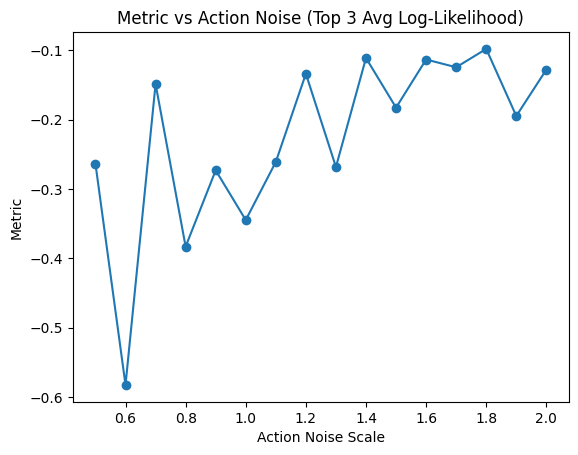

Top 3 Action Noises: [np.float64(1.8), np.float64(1.4), np.float64(1.6)]


In [20]:
action_metrics = {}

for var_scale in variance_scales:
    print(f"Testing action variance {var_scale:.2f}")
    metric, _ = evaluate_proposal(var_scale, num_vehicles=2, n_rollouts=num_rollouts_sweep)
    action_metrics[var_scale] = metric

# Plot
plt.figure()
plt.plot(list(action_metrics.keys()), list(action_metrics.values()), marker='o')
plt.title("Metric vs Action Noise (Top 3 Avg Log-Likelihood)")
plt.xlabel("Action Noise Scale")
plt.ylabel("Metric")
plt.show()

# Save top 3 action noises
top_action_noises = sorted(action_metrics, key=action_metrics.get, reverse=True)[:3]
print("Top 3 Action Noises:", top_action_noises)

Testing vehicles 1
Testing vehicles 2
Testing vehicles 3
Testing vehicles 4
Testing vehicles 5
Testing vehicles 6
Testing vehicles 7
Testing vehicles 8
Testing vehicles 9
Testing vehicles 10


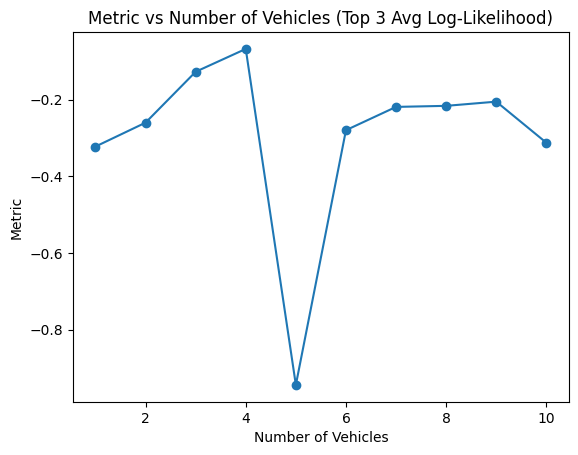

Top 3 Vehicle Counts: [np.int64(4), np.int64(3), np.int64(9)]


In [21]:
env_metrics = {}

for num_vehicles in vehicle_counts:
    print(f"Testing vehicles {num_vehicles}")
    metric, _ = evaluate_proposal(var_scale=0.5, num_vehicles=num_vehicles,
                                   n_rollouts=num_rollouts_sweep)
    env_metrics[num_vehicles] = metric

# Plot
plt.figure()
plt.plot(list(env_metrics.keys()), list(env_metrics.values()), marker='o')
plt.title("Metric vs Number of Vehicles (Top 3 Avg Log-Likelihood)")
plt.xlabel("Number of Vehicles")
plt.ylabel("Metric")
plt.show()

# Save top 3 vehicle counts
top_vehicle_counts = sorted(env_metrics, key=env_metrics.get, reverse=True)[:3]
print("Top 3 Vehicle Counts:", top_vehicle_counts)

Testing nested proposal: variance=1.80, vehicles=4
Testing nested proposal: variance=1.80, vehicles=3
Testing nested proposal: variance=1.80, vehicles=9
Testing nested proposal: variance=1.40, vehicles=4
Testing nested proposal: variance=1.40, vehicles=3
Testing nested proposal: variance=1.40, vehicles=9
Testing nested proposal: variance=1.60, vehicles=4
Testing nested proposal: variance=1.60, vehicles=3
Testing nested proposal: variance=1.60, vehicles=9


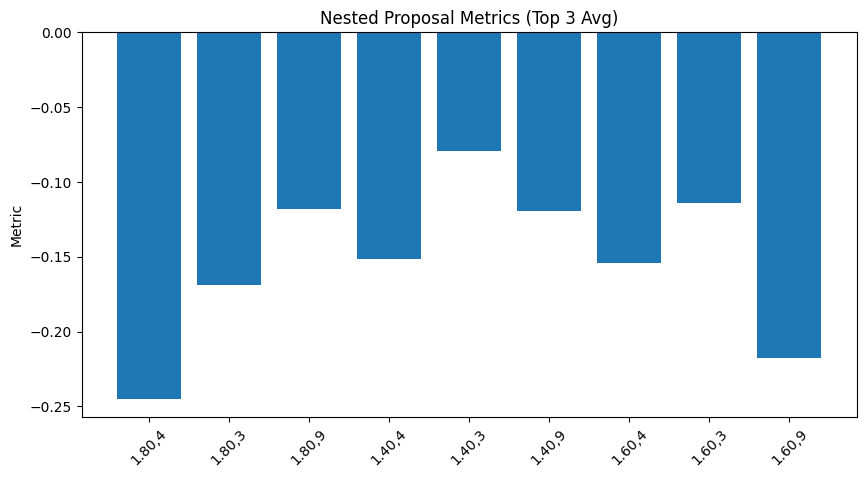

Best Overall Proposal:
Variance: 1.4
Vehicles: 3


In [22]:
nested_metrics = {}

for var_scale in top_action_noises:
    for num_vehicles in top_vehicle_counts:
        print(f"Testing nested proposal: variance={var_scale:.2f}, vehicles={num_vehicles}")
        metric, _ = evaluate_proposal(var_scale, num_vehicles,
                                       n_rollouts=num_rollouts_sweep)
        nested_metrics[(var_scale, num_vehicles)] = metric

# Plot nested scores
labels = [f"{v:.2f},{n}" for (v,n) in nested_metrics.keys()]
values = list(nested_metrics.values())

plt.figure(figsize=(10,5))
plt.bar(labels, values)
plt.xticks(rotation=45)
plt.title("Nested Proposal Metrics (Top 3 Avg)")
plt.ylabel("Metric")
plt.show()

best_proposal = max(nested_metrics, key=nested_metrics.get)
best_var, best_vehicles = best_proposal

print("Best Overall Proposal:")
print("Variance:", best_var)
print("Vehicles:", best_vehicles)

In [23]:
env_vec = make_vec_env('racetrack-v0', n_envs=1, env_kwargs=env_kwargs)
env_single = env_vec.envs[0]
env_single.unwrapped.config["other_vehicles"] = best_vehicles

all_failure_logps = []
all_failures = []

total_rollouts = 0
total_failures = 0

for _ in range(num_rollouts_final):
    failed, logp, frames = run_rollout(env_single, model,
                                       action_variance_scale=best_var)
    total_rollouts += 1

    if failed:
        total_failures += 1
        all_failure_logps.append(logp)
        all_failures.append((logp, frames))

env_vec.close()

print("Total rollouts:", total_rollouts)
print("Total failures:", total_failures)

Total rollouts: 200
Total failures: 200


In [24]:
all_failures.sort(reverse=True, key=lambda x: x[0])

mlf_logp, mlf_video = all_failures[0]
print("Overall MLF log-likelihood:", mlf_logp)

imageio.mimsave("Overall_MLF.mp4", mlf_video, fps=20)

Overall MLF log-likelihood: -0.013882952826525583


In [25]:
thresholds = list(range(0, 100, 10))

for t in thresholds:
    best = None
    best_logp = -np.inf

    for logp, frames in all_failures:
        if len(frames) > t and logp > best_logp:
            best_logp = logp
            best = frames

    if best is not None:
        fname = f"MLF_after_{t}_steps.mp4"
        imageio.mimsave(fname, best, fps=20)
        print(f"Saved {fname}")

Saved MLF_after_0_steps.mp4
Saved MLF_after_10_steps.mp4
Saved MLF_after_20_steps.mp4


In [30]:
Video("MLF_after_0_steps.mp4", embed=True)

In [31]:
Video("MLF_after_10_steps.mp4", embed=True)

In [29]:
Video("MLF_after_20_steps.mp4", embed=True)

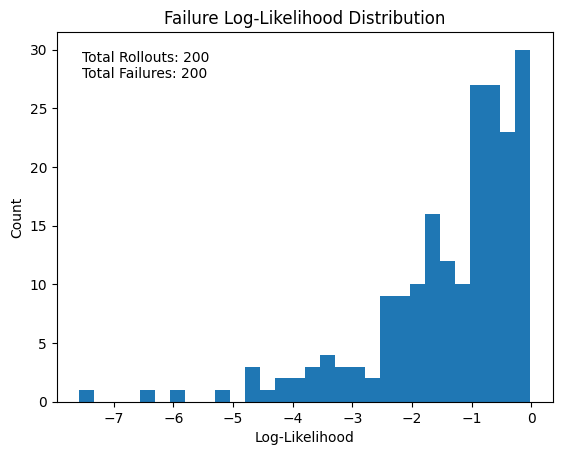

In [27]:
plt.figure()
plt.hist(all_failure_logps, bins=30)
plt.title("Failure Log-Likelihood Distribution")
plt.xlabel("Log-Likelihood")
plt.ylabel("Count")

plt.text(0.05, 0.95,
         f"Total Rollouts: {total_rollouts}\nTotal Failures: {total_failures}",
         transform=plt.gca().transAxes,
         verticalalignment='top')

plt.show()

# Importance Sampling

In [44]:
def gaussian_log_prob(x, mean, std):
    """
    Full multivariate diagonal Gaussian log density.
    x, mean: numpy arrays
    std: scalar (same std for all dimensions)
    """
    var = std ** 2
    return -0.5 * np.sum(
        ((x - mean) ** 2) / var
        + np.log(2 * np.pi * var)
    )

In [45]:
def run_rollout_IS(env, model, proposal_std, nominal_std, max_steps=500):
    """
    Performs one rollout under proposal distribution
    and computes trajectory log-likelihood under:

        q = proposal distribution
        p = nominal distribution

    Returns:
        failed (bool)
        logp_p (float)
        logp_q (float)
    """

    obs, info = env.reset()
    done, truncated = False, False

    logp_q = 0.0
    logp_p = 0.0
    step = 0

    while not (done or truncated) and step < max_steps:

        # Deterministic base action
        action, _ = model.predict(obs, deterministic=True)

        # Sample proposal noise
        noise = np.random.normal(
            loc=0.0,
            scale=proposal_std,
            size=action.shape
        )

        action_noisy = action + noise  # DO NOT CLIP

        # Accumulate trajectory log-likelihoods
        logp_q += gaussian_log_prob(action_noisy, action, proposal_std)
        logp_p += gaussian_log_prob(action_noisy, action, nominal_std)

        obs, reward, done, truncated, info = env.step(action_noisy)
        step += 1

    failed = done  # crash/off-road only (not timeout)

    return failed, logp_p, logp_q

In [ ]:
def importance_sampling_estimate(
    env,
    model,
    proposal_std,
    nominal_std=0.5,
    max_rollouts=100
):

    pf_estimates = []
    weights_sum = 0.0
    N = 0

    for i in range(max_rollouts):

        failed, logp_p, logp_q = run_rollout_IS(
            env,
            model,
            proposal_std,
            nominal_std
        )

        log_weight = logp_p - logp_q

        # Prevent numerical explosion
        log_weight = np.clip(log_weight, -50, 50)

        weight = np.exp(log_weight)

        indicator = 1.0 if failed else 0.0

        weights_sum += indicator * weight
        N += 1

        pf_hat = weights_sum / N
        pf_estimates.append(pf_hat)

    return pf_estimates

In [ ]:
pf_estimates = importance_sampling_estimate(
    env_single,
    model,
    proposal_std=best_var,
    nominal_std=0.5,
    max_rollouts=100
)

plt.figure()
plt.plot(pf_estimates)
plt.xlabel("Number of Rollouts")
plt.ylabel("Estimated Probability of Failure")
plt.title("Importance Sampling Convergence")
plt.show()

In [46]:
weights = []

for _ in range(50):
    _, logp_p, logp_q = run_rollout_IS(
        env_single,
        model,
        proposal_std=best_var,
        nominal_std=0.5
    )
    weights.append(np.exp(logp_p - logp_q))

print("Mean weight:", np.mean(weights))

Mean weight: 0.07260511954479125


# Estimate Ground Truth Probability of Failure

In [40]:
def run_rollout_nominal(env, model, action_noise_scale=0.5):
    """
    Rollout under nominal distribution ONLY.
    No likelihood computation.
    Returns: failed (bool)
    """

    obs, _ = env.reset()
    done = False
    failed = False

    while not done:
        obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)

        with torch.no_grad():
            action, _ = model.predict(obs, deterministic=False)

        # Add Gaussian noise manually
        noise = np.random.normal(
            loc=0.0,
            scale=action_noise_scale,
            size=action.shape
        )

        noisy_action = action + noise

        obs, reward, terminated, truncated, info = env.step(noisy_action)
        done = terminated or truncated

        # Define failure condition carefully
        if terminated:
            failed = True

    return failed

In [41]:
def estimate_ground_truth_failure(
    env,
    model,
    nominal_action_noise=0.5,
    max_rollouts=1000
):

    failures = []
    running_estimates = []

    for i in range(1, max_rollouts + 1):

        failed = run_rollout_nominal(
            env,
            model,
            action_noise_scale=nominal_action_noise
        )

        failures.append(1 if failed else 0)
        p_hat = np.mean(failures)
        running_estimates.append(p_hat)

        if i % 50 == 0:
            print(f"Rollouts: {i}, Estimate: {p_hat:.4f}")

    print(f"\nFinal Monte Carlo estimate: {running_estimates[-1]:.6f}")

    return running_estimates

Rollouts: 50, Estimate: 1.0000
Rollouts: 100, Estimate: 1.0000

Final Monte Carlo estimate: 1.000000


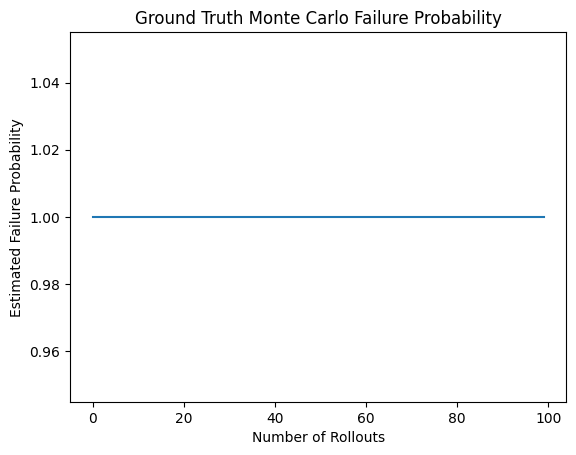

In [42]:
gt_estimates = estimate_ground_truth_failure(
    env_single,
    model,
    nominal_action_noise=0.5,
    max_rollouts=100
)

plt.figure()
plt.plot(gt_estimates)
plt.xlabel("Number of Rollouts")
plt.ylabel("Estimated Failure Probability")
plt.title("Ground Truth Monte Carlo Failure Probability")
plt.show()